In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs;import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

In [2]:
dir = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# dx = 250m; Np = 50M
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
res='250m'; t_res='1min'; Np_str='50e6'

In [3]:
# gndirt
# Description: Infrared Thermometer: Ground surface temperature
# Site: Houston, TX; Tracking Aerosol Convection interactions ExpeRiment (HOU)
# Location: Houston, TX; AMF1 (main site for TRACER) 
# Facility Code: M1
# Category: Radiometric
# Data Type: Routine Data 
# Source Instrument/Data: Infrared Thermometer 
# Start Date: 2021-08-04 
# End Date: 2022-10-01 

In [4]:
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
def GetLandData(search_date):
    import glob
    import xarray as xr
    
    data_location = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'
    
    # Search for files containing "20220622"
    matching_files = glob.glob(f"{data_location}*{search_date}*.nc")
    
    # Open the first matching file if it exists
    if matching_files:
        file_to_open = matching_files[0]  # Take the first match
        # print(f"Opening file: {file_to_open}")
        ds = xr.open_dataset(file_to_open)
    else:
        print("No file found for the given date.")
    return ds

In [5]:
# ds=GetLandData('20220622')
# ###########################################################################################
# ds['time'] = ds['time'] - np.timedelta64(5, 'h')
# timestamps=ds['time']

# search_date = "2022-06-22"

# # Find matching timestamps
# matches = np.char.startswith(timestamps.astype(str), search_date)
# where=np.where(matches==True)

# true_data=ds['sfc_ir_temp'][where].values

# start_time = pd.Timestamp(timestamps[0].values)  # First timestamp
# end_time = pd.Timestamp(timestamps[-1].values)   # Last timestamp

# # Generate new time array with interpolated values (e.g., every 10 minutes)
# new_time_values = pd.date_range(start=start_time, end=end_time, periods=len(true_data))

# # Plot with the new interpolated time axis
# plt.plot(new_time_values, true_data, alpha=0.75, color='green', label='Observed Land Data')
# plt.ylabel('T (K)')
# plt.xticks(rotation=45);
# plt.title('Diurnal Cycle')
# ###########################################################################################
# print(len(new_time_values))

1140


Text(0.5, 1.0, 'Diurnal Cycle and 15 Day Average Around Date')

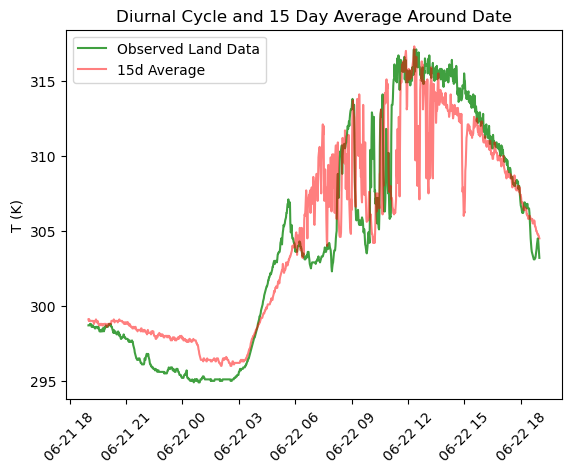

In [6]:

ds=GetLandData('20220622')
###########################################################################################
ds['time'] = ds['time'] - np.timedelta64(5, 'h')
timestamps=ds['time']

search_date = "2022-06-22"

# Find matching timestamps
matches = np.char.startswith(timestamps.astype(str), search_date)
where=np.where(matches==True)

true_data=ds['sfc_ir_temp'][where].values

start_time = pd.Timestamp(timestamps[0].values)  # First timestamp
end_time = pd.Timestamp(timestamps[-1].values)   # Last timestamp

# Generate new time array with interpolated values (e.g., every 10 minutes)
new_time_values = pd.date_range(start=start_time, end=end_time, periods=len(true_data))

# Plot with the new interpolated time axis
plt.plot(new_time_values, true_data, alpha=0.75, color='green', label='Observed Land Data')
plt.ylabel('T (K)')
plt.xticks(rotation=45);
###########################################################################################
print(len(new_time_values))

#15 Day Average Diurnal Cycle
###########################################################################################

avgArray=np.zeros((1,1140))


# Define data location
data_location = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'

# Define search date range (June 7 to July 7, 2022)
start_date = pd.Timestamp("2022-06-07")
end_date = pd.Timestamp("2022-07-07")

# Generate list of dates in YYYYMMDD format
search_dates = [(start_date + pd.Timedelta(days=i)).strftime("%Y%m%d") for i in range((end_date - start_date).days + 1)]

count=0
for ind in np.arange(len(search_dates)):
    ds = GetLandData(search_dates[ind])

    ###########################################################################################
    ds['time'] = ds['time'] - np.timedelta64(5, 'h')
    timestamps=ds['time']
    
    # search_date = "2022-06-22"
    search_date=search_dates[ind]
    search_date = datetime.strptime(search_date, "%Y%m%d").strftime("%Y-%m-%d")
    
    # Find matching timestamps
    matches = np.char.startswith(timestamps.astype(str), search_date)
    where=np.where(matches==True)

    true_data=ds['sfc_ir_temp'][where].values

    # start_time = pd.Timestamp(timestamps[0].values)  # First timestamp
    # end_time = pd.Timestamp(timestamps[-1].values)   # Last timestamp

    # # Generate new time array with interpolated values (e.g., every 10 minutes)
    # new_time_values = pd.date_range(start=start_time, end=end_time, periods=len(true_data))
    # print(new_time_values);print('\n')
    
    if len(true_data) == 1140: #excluding 06/08/22
        count+=1
        avgArray+=true_data
avgArray/=count

# Plot with the new interpolated time axis
plt.plot(new_time_values, true_data, alpha=0.5, color='red', label='15d Average')
plt.ylabel('T (K)')
plt.xticks(rotation=45);
###########################################################################################
plt.legend()

plt.title('Diurnal Cycle and 15 Day Average Around Date')

In [7]:
#Description: ERA5 hourly data on single levels from 1940 to present

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import pandas as pd

def load_data(data_location):
    data = xr.open_dataset(data_location+'/era5.nc') 
    data['valid_time'] = data['valid_time'] - np.timedelta64(5, 'h')
    return data

def extract_data_subset(data):
    timestamps = data['valid_time'].values.astype(str)
    t_where = np.where(np.char.startswith(timestamps, '2022-06-22T11'))[0]

    bot_lat_ind,top_lat_ind=25,38
    left_lon_ind,right_lon_ind=255,270
    bot_lat=data['latitude'][bot_lat_ind].item()
    top_lat=data['latitude'][top_lat_ind].item()
    left_lon=data['longitude'][left_lon_ind].item()
    right_lon=data['longitude'][right_lon_ind].item()
    sst_og = data['sst'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))
    skt_og = data['skt'].sel(latitude=slice(top_lat_ind,bot_lat_ind),longitude=slice(left_lon_ind,right_lon_ind))

    sst=sst_og.isel(valid_time=t_where)[0]
    sst=sst.assign_coords(longitude=((sst_og.longitude + 180) % 360 - 180)) # Convert longitudes from 0-360 to -180 to 180
    skt=skt_og.isel(valid_time=t_where)[0]
    skt=skt.assign_coords(longitude=((sst_og.longitude + 180) % 360 - 180)) # Convert longitudes from 0-360 to -180 to 180
    sst = sst.isel(latitude=slice(None, None, -1))  # Flip latitude
    skt = skt.isel(latitude=slice(None, None, -1))  # Flip latitude

    return sst_og, skt_og, sst, skt, t_where, timestamps, bot_lat, top_lat, left_lon, right_lon

def create_figure():
    fig = plt.figure(figsize=(12, 10), dpi=100)
    gs = GridSpec(nrows=2, ncols=2, figure=fig, height_ratios=[1, 1], width_ratios=[3, 2])
    return fig, gs

def plot_main_map(fig, gs, skt, timestamps, t_where, land_lat, land_lon, ocean_lat, ocean_lon):
    ax1 = fig.add_subplot(gs[:, 0], projection=ccrs.PlateCarree())
    contour = ax1.contourf(skt['longitude'], skt['latitude'],skt, transform=ccrs.PlateCarree(), cmap='viridis')
    cbar = plt.colorbar(contour, ax=ax1, shrink=0.7)
    cbar.set_label("Skin Temperature (K)", fontsize=12)

    ax1.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    ax1.add_feature(cfeature.STATES, linestyle='-', edgecolor='black')
    ax1.coastlines()

    lon_min, lon_max = skt.longitude.min().item(), skt.longitude.max().item()
    lat_min, lat_max = skt.latitude.min().item(), skt.latitude.max().item()

    lon_ticks = np.linspace(lon_min, lon_max, num=8)
    lat_ticks = np.linspace(lat_min, lat_max, num=12)

    ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax1.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax1.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

    ax1.set_xticklabels([f"{lon:.1f}°" for lon in lon_ticks], fontsize=10)
    ax1.set_yticklabels([f"{lat:.1f}°" for lat in lat_ticks], fontsize=10)

    ax1.scatter(land_lon, land_lat, color='brown', label="Land Point")  # Land point
    ax1.scatter(ocean_lon, ocean_lat, color='blue', label="Ocean Point")  # Ocean point

    landtemp_val=skt.sel(latitude=land_lat,longitude=land_lon,method='nearest').item()
    oceantemp_val=skt.sel(latitude=ocean_lat,longitude=ocean_lon,method='nearest').item()
    ax1.text(0.5, 1.05, f'Land temperature: {landtemp_val:.2f} °C | Ocean temperature: {oceantemp_val:.2f} °C',  
             ha='center', va='bottom', fontsize=10, transform=ax1.transAxes)

    ax1.axvline(land_lon,linestyle='dashed',color='grey')
    ax1.axhline(land_lat,linestyle='dashed',color='grey')
    ax1.axvline(ocean_lon,linestyle='dashed',color='blue',alpha=0.4)
    ax1.axhline(ocean_lat,linestyle='dashed',color='blue',alpha=0.4)

    ax1.set_title(f'Time = {timestamps[t_where[0]][:13]}:00 UTC-5 (LT)', fontsize=10)
    ax1.legend(loc="upper right", fontsize=10)

    return ax1

def plot_era5_lineplot(fig, gs, sst_og, skt_og, land_lat, land_lon, ocean_lat, ocean_lon):
    sst_og = sst_og.assign_coords(longitude=((sst_og.longitude + 180) % 360 - 180))
    skt_og = skt_og.assign_coords(longitude=((skt_og.longitude + 180) % 360 - 180))
    skt_diurnal_land=skt_og.sel(latitude=land_lat,longitude=land_lon,method='nearest').values
    skt_diurnal_ocean=skt_og.sel(latitude=ocean_lat,longitude=ocean_lon,method='nearest').values

    time_values = pd.to_datetime(skt_og['valid_time'].values)

    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(time_values,skt_diurnal_land, color='brown',label='ERA-5 Land')
    ax2.plot(time_values,skt_diurnal_ocean, color='blue',label='ERA-5 Ocean')

    even_indices = np.arange(1, len(time_values), 2)  # Step of 2 ensures even indices
    ax2.set_xticks(time_values[even_indices])  
    ax2.set_xticklabels(time_values[even_indices].strftime('%H:%M'), rotation=45, fontsize=10)

    return ax2, skt_diurnal_land, skt_diurnal_ocean, time_values

def plot_real_data_lineplot(ax2):
    ds=GetLandData('20220622')
    ds['time'] = ds['time'] - np.timedelta64(5, 'h')
    timestamps_true=ds['time']

    search_date = "2022-06-22"
    matches = np.char.startswith(timestamps_true.astype(str), search_date)
    where=np.where(matches==True)

    true_data=ds['sfc_ir_temp'][where].values

    start_time = pd.Timestamp(timestamps_true[0].values)  # First timestamp
    end_time = pd.Timestamp(timestamps_true[-1].values)   # Last timestamp

    true_time_values = pd.date_range(start=start_time, end=end_time, periods=len(true_data))

    ax2.plot(true_time_values, true_data, alpha=0.75, color='green', label='Observed Land')
    return ax2, true_data, true_time_values

def set_yticks(ax2, skt_diurnal_land, skt_diurnal_ocean, true_data):
    y_min = min(skt_diurnal_land.min(), skt_diurnal_ocean.min(),true_data.min())  
    y_max = max(skt_diurnal_land.max(), skt_diurnal_ocean.max(),true_data.max())  
    num_ticks = 10  # Adjust number of ticks as needed
    y_ticks = np.linspace(y_min, y_max, num=num_ticks)
    ax2.set_yticks(y_ticks);

def print_temperatures(timestamps, skt_diurnal_land, true_time_values, true_data, skt_diurnal_ocean):
    land_start = np.where(np.char.startswith(timestamps, '2022-06-22T06'))[0]
    print(f'Model-Start Land Temperature from ERA-5 = {skt_diurnal_land[land_start][0]:.2f}')
    target_time = pd.Timestamp("2022-06-22 06:00:00")
    land_start_true = np.argmin(np.abs(true_time_values - target_time))
    print(f'Model-Start Land Temperature from True Data = {true_data[land_start_true]:.2f}')
    print(f'Average Ocean Temperature = {skt_diurnal_ocean.mean():.2f}')

def plot_15_day_average_diurnal_cycle(ax2, GetLandData): #NOT TESTED
    ###########################################################################################
    # 15 Day Average Diurnal Cycle
    ###########################################################################################
    import numpy as np
    import pandas as pd
    from datetime import datetime

    avgArray = np.zeros((1, 1140))

    # Define data location
    data_location = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/surface_data/'

    # Define search date range (June 7 to July 7, 2022)
    start_date = pd.Timestamp("2022-06-07")
    end_date = pd.Timestamp("2022-07-07")

    # Generate list of dates in YYYYMMDD format
    search_dates = [(start_date + pd.Timedelta(days=i)).strftime("%Y%m%d") for i in range((end_date - start_date).days + 1)]

    count = 0
    for ind in np.arange(len(search_dates)):
        ds = GetLandData(search_dates[ind])

        ###########################################################################################
        ds['time'] = ds['time'] - np.timedelta64(5, 'h')
        timestamps = ds['time']

        search_date = search_dates[ind]
        search_date = datetime.strptime(search_date, "%Y%m%d").strftime("%Y-%m-%d")

        # Find matching timestamps
        matches = np.char.startswith(timestamps.astype(str), search_date)
        where = np.where(matches == True)

        true_data = ds['sfc_ir_temp'][where].values

        if len(true_data) == 1140:  # excluding 06/08/22
            count += 1
            avgArray += true_data

    avgArray /= count

    # Create time axis based on one valid day (you could choose any, here using final one)
    start_time = pd.Timestamp("2022-06-22 06:00:00")
    end_time = pd.Timestamp("2022-06-22 17:00:00")
    new_time_values = pd.date_range(start=start_time, end=end_time, periods=1140)

    # Plot on ax2 instead of plt
    ax2.plot(new_time_values, avgArray.flatten(), alpha=0.5, color='red', label='Observed Land Avg')
    ax2.set_ylabel('T (K)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()
    ###########################################################################################
    return ax2


def LoadLandOceanData(filename=dir+'Figures/campaign_data/'+f'land_ocean_data_{res}_{t_res}.pkl'):
    import pickle
    with open(filename, 'rb') as f:
        data_list = pickle.load(f)
    return data_list[0], data_list[1]

def plot_model_data(ax2, true_data):
    ###############################################################################################################
    #LOADING IN MODEL DATA FOR LINEPLOT #*#*#*#
    ###########################################################################################
    model_data=True
    if model_data==True:
        import numpy as np
        import matplotlib.pyplot as plt
        import xarray as xr
        import matplotlib.ticker as ticker
        n_bins=10
        hours_per_timestep=60/5
        previous_hours=11
        previous_times=-hours_per_timestep*previous_hours

        # Load dataset
        [land_data,ocean_data]=LoadLandOceanData()#CREATED IN MODEL_DIURNAL_CYCLE.py

        model_start_time = pd.Timestamp("2022-06-22 06:00:00")  
        model_end_time = pd.Timestamp("2022-06-22 17:00:00")
        
        # Generate new time array with interpolated values (same length as true_data)
        model_time_values = pd.date_range(start=model_start_time, end=model_end_time, periods=len(land_data))
        ax2.plot(model_time_values,land_data, color='brown', linestyle='dashed', label='Model Land')
        ax2.plot(model_time_values,ocean_data, color='blue', linestyle='dashed', label='Model Ocean')
    ###########################################################################################
    return ax2


Model-Start Land Temperature from ERA-5 = 298.95
Model-Start Land Temperature from True Data = 303.70
Average Ocean Temperature = 303.13


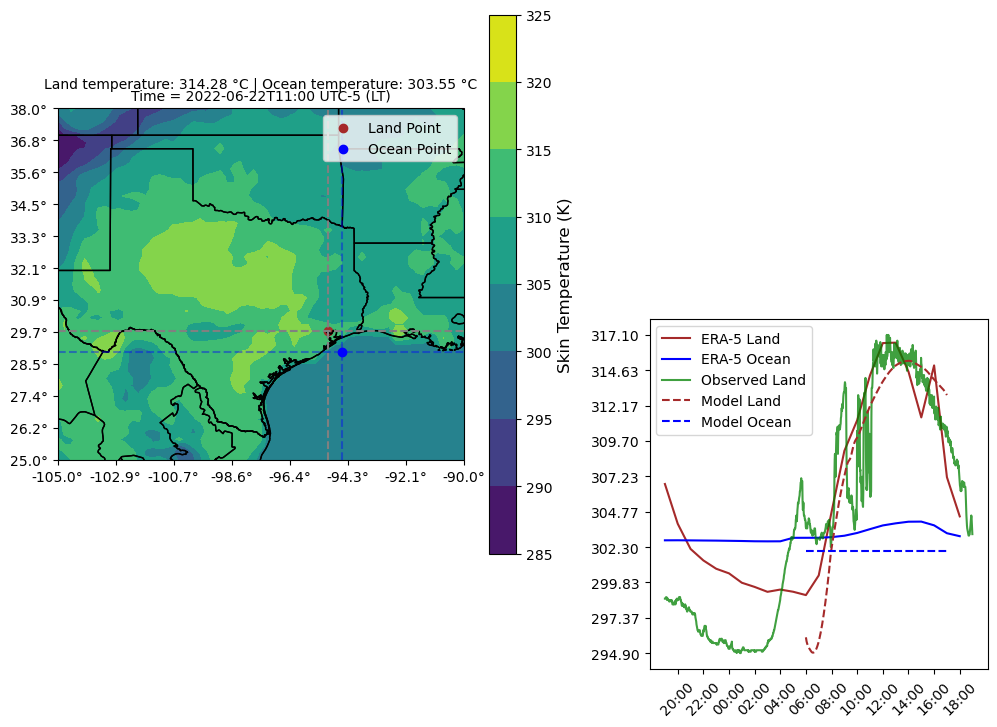

In [9]:
def main():
    data_location='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data'

    era_data = load_data(data_location)
    sst_og, skt_og, sst, skt, t_where, timestamps, bot_lat, top_lat, left_lon, right_lon = extract_data_subset(era_data)

    land_lat = 29.75
    ocean_lat = 29
    land_lon = -95  
    ocean_lon = -94.5

    fig, gs = create_figure()

    ax1 = plot_main_map(fig, gs, skt, timestamps, t_where, land_lat, land_lon, ocean_lat, ocean_lon)

    ax2, skt_diurnal_land, skt_diurnal_ocean, time_values = plot_era5_lineplot(fig, gs, sst_og, skt_og, land_lat, land_lon, ocean_lat, ocean_lon)

    ax2, true_data, true_time_values = plot_real_data_lineplot(ax2)
    # ax2 = plot_15_day_average_diurnal_cycle(ax2, GetLandData) #NOT TESTED

    ax2 = plot_model_data(ax2, true_data)

    

    set_yticks(ax2, skt_diurnal_land, skt_diurnal_ocean, true_data)

    print_temperatures(timestamps, skt_diurnal_land, true_time_values, true_data, skt_diurnal_ocean)

    ax2.legend(loc='upper left')
    plt.show()


if __name__ == "__main__":
    main()